# Ansatz Comparison: H2

This notebook compares all packaged VQE ansätze on the hydrogen molecule **H2**.

The ansatz list is taken directly from the canonical registry in `vqe.ansatz.ANSATZES`, so the notebook automatically stays aligned with the packaged implementation.

Goals:

- run the same optimization workflow with every registered packaged ansatz
- compare convergence behaviour
- compare final energies against the exact ground-state reference

This is a simple way to see how ansatz choice changes variational performance.


In [9]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

from vqe.core import run_vqe
from vqe.ansatz import ANSATZES
from common.hamiltonian import get_exact_spectrum

## Setup

We keep the molecule, optimizer, step count, and random seed fixed.

Only the ansatz changes, and the compared ansätze are taken directly from `vqe.ansatz.ANSATZES`.


In [10]:
molecule = "H2"
optimizer_name = "Adam"
steps = 75
stepsize = 0.2
seed = 0

# Compare every ansatz currently registered in the package.
ansatz_names = sorted(ANSATZES)
ansatz_names


['Minimal',
 'RY-CZ',
 'StronglyEntanglingLayers',
 'TwoQubit-RY-CNOT',
 'UCCD',
 'UCCS',
 'UCCSD']

## Exact ground-state reference

For a small system like `H2`, we can compare each variational result against
the exact ground-state energy.

In [11]:
exact_spectrum = np.asarray(get_exact_spectrum(molecule), dtype=float)
exact_spectrum = np.sort(exact_spectrum)
exact_ground_energy = float(exact_spectrum[0])

exact_ground_energy

-1.1372701748841751

## Run VQE for each ansatz

In [12]:
results = {}

for ansatz_name in ansatz_names:
    print(f"Running {ansatz_name} ...")
    res = run_vqe(
        molecule=molecule,
        ansatz_name=ansatz_name,
        optimizer_name=optimizer_name,
        steps=steps,
        stepsize=stepsize,
        seed=seed,
        noisy=False,
        force=False,
        plot=False,
    )
    results[ansatz_name] = res

Running Minimal ...
Running RY-CZ ...
Running StronglyEntanglingLayers ...
Running TwoQubit-RY-CNOT ...


Running UCCD ...
Running UCCS ...
Running UCCSD ...


## Final energies

In [13]:
summary_rows = []

for ansatz_name, res in results.items():
    final_energy = float(res["energy"])
    abs_error = abs(final_energy - exact_ground_energy)
    n_steps = len(res["energies"])

    summary_rows.append((ansatz_name, final_energy, abs_error, n_steps))

summary_rows

[('Minimal', -1.116098667401199, 0.021171507482976137, 76),
 ('RY-CZ', -1.1154173979742241, 0.02185277690995102, 76),
 ('StronglyEntanglingLayers', -1.1349428186714396, 0.0023273562127354985, 76),
 ('TwoQubit-RY-CNOT', -1.1135660327799517, 0.023704142104223447, 76),
 ('UCCD', -1.1372684143722134, 1.7605119617680742e-06, 76),
 ('UCCS', -1.1166806272651975, 0.020589547618977688, 76),
 ('UCCSD', -1.1372675666881946, 2.6081959805246413e-06, 76)]

In [14]:
for ansatz_name, final_energy, abs_error, n_steps in summary_rows:
    print(
        f"{ansatz_name:>24} | "
        f"final = {final_energy:.10f} | "
        f"abs error = {abs_error:.6e} | "
        f"steps = {n_steps}"
    )

                 Minimal | final = -1.1160986674 | abs error = 2.117151e-02 | steps = 76
                   RY-CZ | final = -1.1154173980 | abs error = 2.185278e-02 | steps = 76
StronglyEntanglingLayers | final = -1.1349428187 | abs error = 2.327356e-03 | steps = 76
        TwoQubit-RY-CNOT | final = -1.1135660328 | abs error = 2.370414e-02 | steps = 76
                    UCCD | final = -1.1372684144 | abs error = 1.760512e-06 | steps = 76
                    UCCS | final = -1.1166806273 | abs error = 2.058955e-02 | steps = 76
                   UCCSD | final = -1.1372675667 | abs error = 2.608196e-06 | steps = 76


## Convergence curves

Plot the energy trajectory for each ansatz on the same axes.

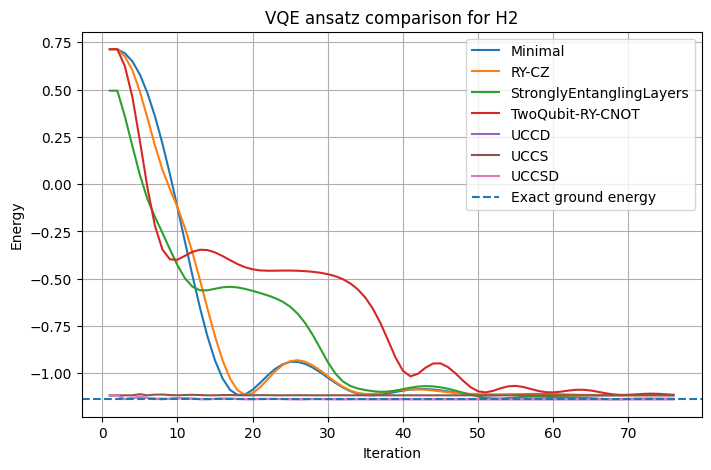

In [15]:
plt.figure(figsize=(8, 5))

for ansatz_name, res in results.items():
    energies = np.asarray(res["energies"], dtype=float)
    plt.plot(
        np.arange(1, len(energies) + 1),
        energies,
        label=ansatz_name,
    )

plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE ansatz comparison for H2")
plt.grid(True)
plt.legend()
plt.show()


## Final-energy comparison

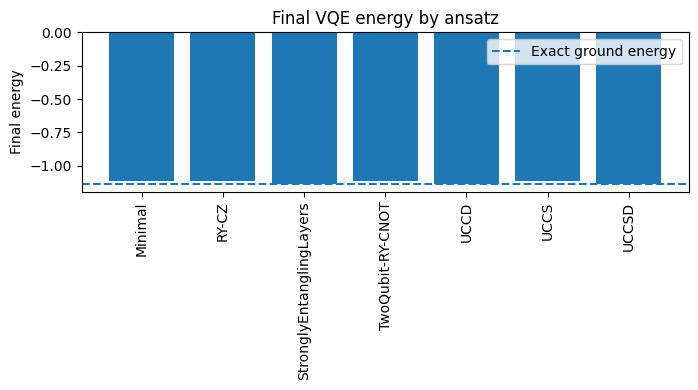

In [16]:
final_energies = [float(results[name]["energy"]) for name in ansatz_names]

plt.figure(figsize=(7, 4))
plt.bar(ansatz_names, final_energies)
plt.axhline(exact_ground_energy, linestyle="--", label="Exact ground energy")
plt.ylabel("Final energy")
plt.title("Final VQE energy by ansatz")
plt.xticks(rotation=90)
plt.tight_layout()
plt.legend()
plt.show()


## Interpretation

Typical things to look for:

- which ansatz reaches the lowest final energy
- which ansatz converges fastest
- which ansatz appears most stable during optimization

For small chemistry problems, **UCCSD** is often a strong baseline because it
incorporates chemically motivated excitation structure.

Simpler ansätze can still be useful:

- **Minimal** for pedagogy and debugging
- **RY-CZ** for lightweight hardware-oriented baselines

## What this notebook showed

We:

- ran VQE on the same molecule with multiple ansätze
- compared convergence curves
- compared final energies to the exact ground-state reference

This isolates the effect of ansatz choice while keeping the rest of the
workflow fixed.